<a href="https://colab.research.google.com/github/Atul723/colab_sheets/blob/main/steps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
%pip install -r /content/drive/MyDrive/steps_analysis/requirements.txt

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:

df = pd.read_csv("/content/drive/MyDrive/steps_analysis/dataset/steps_data_august_2026.csv")
df.head(10)


,Date,Time,Steps,Source
0,2026.08.01 12:47:55,12:47:55,7,com.google.android.apps.fitness
1,2026.08.01 12:47:55,12:47:55,7,com.fitbit.FitbitMobile
2,2026.08.01 12:48:55,12:48:55,7,com.google.android.apps.fitness
3,2026.08.01 12:48:55,12:48:55,7,com.fitbit.FitbitMobile
4,2026.08.01 12:54:55,12:54:55,1,com.google.android.apps.fitness
5,2026.08.01 12:54:55,12:54:55,1,com.fitbit.FitbitMobile
6,2026.08.01 12:55:55,12:55:55,21,com.google.android.apps.fitness
7,2026.08.01 12:55:55,12:55:55,21,com.fitbit.FitbitMobile
8,2026.08.01 13:06:55,13:06:55,1,com.google.android.apps.fitness
9,2026.08.01 13:06:55,13:06:55,1,com.fitbit.FitbitMobile


In [21]:
len(df)

12132

In [22]:
df=df.drop_duplicates(subset=['Date','Time','Steps'],keep='first')
df.head(10)

,Date,Time,Steps,Source
0,2026.08.01 12:47:55,12:47:55,7,com.google.android.apps.fitness
2,2026.08.01 12:48:55,12:48:55,7,com.google.android.apps.fitness
4,2026.08.01 12:54:55,12:54:55,1,com.google.android.apps.fitness
6,2026.08.01 12:55:55,12:55:55,21,com.google.android.apps.fitness
8,2026.08.01 13:06:55,13:06:55,1,com.google.android.apps.fitness
10,2026.08.01 13:07:55,13:07:55,20,com.google.android.apps.fitness
12,2026.08.01 13:08:55,13:08:55,17,com.google.android.apps.fitness
14,2026.08.01 13:09:55,13:09:55,68,com.google.android.apps.fitness
16,2026.08.01 13:10:54,13:10:54,1,com.google.android.apps.fitness
17,2026.08.01 13:44:55,13:44:55,5,com.google.android.apps.fitness


In [23]:
len(df)

7607

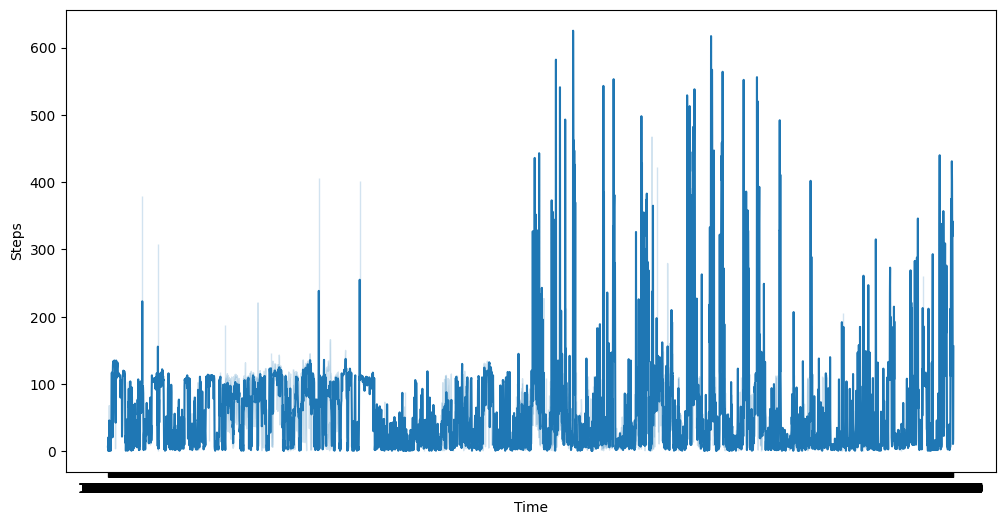

In [24]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Time', y='Steps')
plt.show()

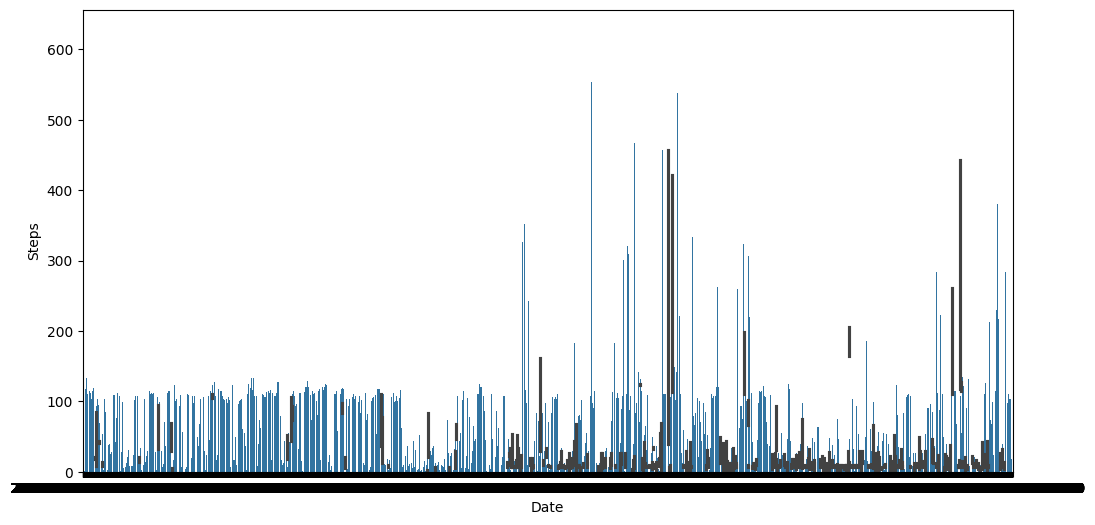

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Date', y='Steps')
plt.show()

In [26]:
df['Date'] = pd.to_datetime(df['Date']).dt.date
daily_steps = df.groupby('Date')['Steps'].sum().reset_index()
display(daily_steps)

,Date,Steps
0,2026-08-01,19734
1,2026-08-02,8402
2,2026-08-03,11939
3,2026-08-04,8333
4,2026-08-05,11308
5,2026-08-06,20109
6,2026-08-07,5422
7,2026-08-08,18388
8,2026-08-09,16810
9,2026-08-10,14383


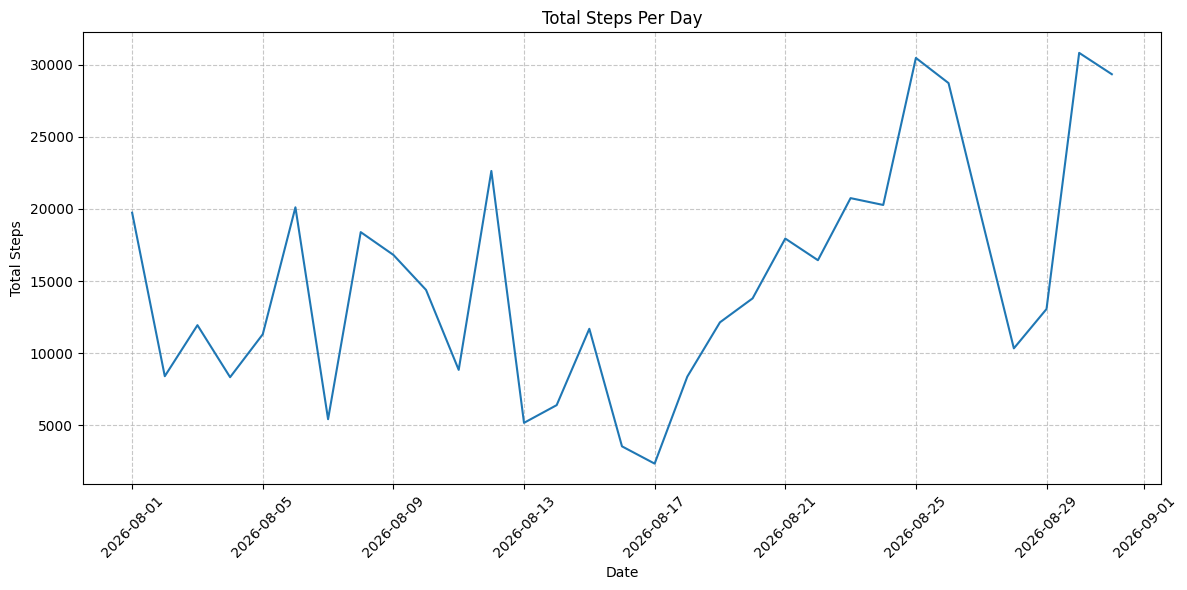

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_steps, x='Date', y='Steps')
plt.title('Total Steps Per Day')
plt.xlabel('Date')
plt.ylabel('Total Steps')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Time-of-Day Steps Analysis

This analysis processes `steps_data_august_2026.csv` to understand step patterns throughout the day. We categorize the data into four distinct 6-hour intervals:
*   **Morning:** 06:00 - 11:59
*   **Afternoon:** 12:00 - 17:59
*   **Evening:** 18:00 - 23:59
*   **Night:** 00:00 - 05:59

The code below handles the data transformation, group aggregation, and visualizes the final distribution.

In [29]:
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])


df['Hour'] = df['DateTime'].dt.hour

def get_time_category(hour):
    if 6 <= hour < 12:
        return 'Morning (6am-12pm)'
    elif 12 <= hour < 18:
        return 'Afternoon (12pm-6pm)'
    elif 18 <= hour < 24:
        return 'Evening (6pm-12am)'
    else:
        return 'Night (12am-6am)'

df['Time_Category'] = df['Hour'].apply(get_time_category)


display(df.head())

steps_by_time_category = df.groupby('Time_Category')['Steps'].sum().reindex([
    'Night (12am-6am)', 'Morning (6am-12pm)', 'Afternoon (12pm-6pm)', 'Evening (6pm-12am)'
])
display(steps_by_time_category)

,Date,Time,Steps,Source,DateTime,Hour,Time_Category
0,2026-08-01,12:47:55,7,com.google.android.apps.fitness,2026-08-01 12:47:55,12,Afternoon (12pm-6pm)
2,2026-08-01,12:48:55,7,com.google.android.apps.fitness,2026-08-01 12:48:55,12,Afternoon (12pm-6pm)
4,2026-08-01,12:54:55,1,com.google.android.apps.fitness,2026-08-01 12:54:55,12,Afternoon (12pm-6pm)
6,2026-08-01,12:55:55,21,com.google.android.apps.fitness,2026-08-01 12:55:55,12,Afternoon (12pm-6pm)
8,2026-08-01,13:06:55,1,com.google.android.apps.fitness,2026-08-01 13:06:55,13,Afternoon (12pm-6pm)


,Steps
Time_Category,
Night (12am-6am),286
Morning (6am-12pm),109474
Afternoon (12pm-6pm),66901
Evening (6pm-12am),290668


/tmp/ipykernel_4304/2180147520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=steps_by_time_category.index, y=steps_by_time_category.values, palette='viridis')


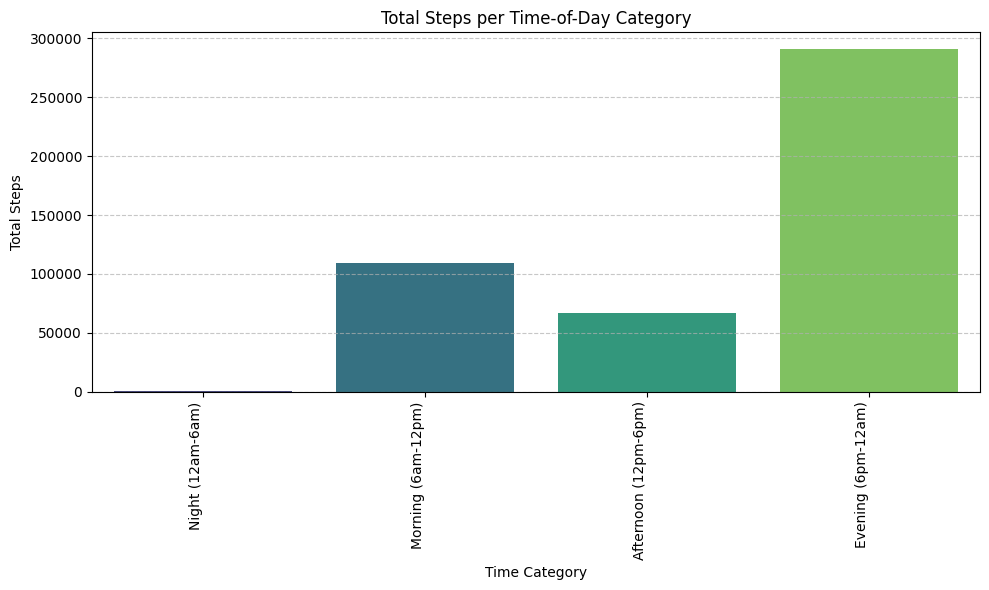

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x=steps_by_time_category.index, y=steps_by_time_category.values, palette='viridis')
plt.title('Total Steps per Time-of-Day Category')
plt.xlabel('Time Category')
plt.ylabel('Total Steps')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

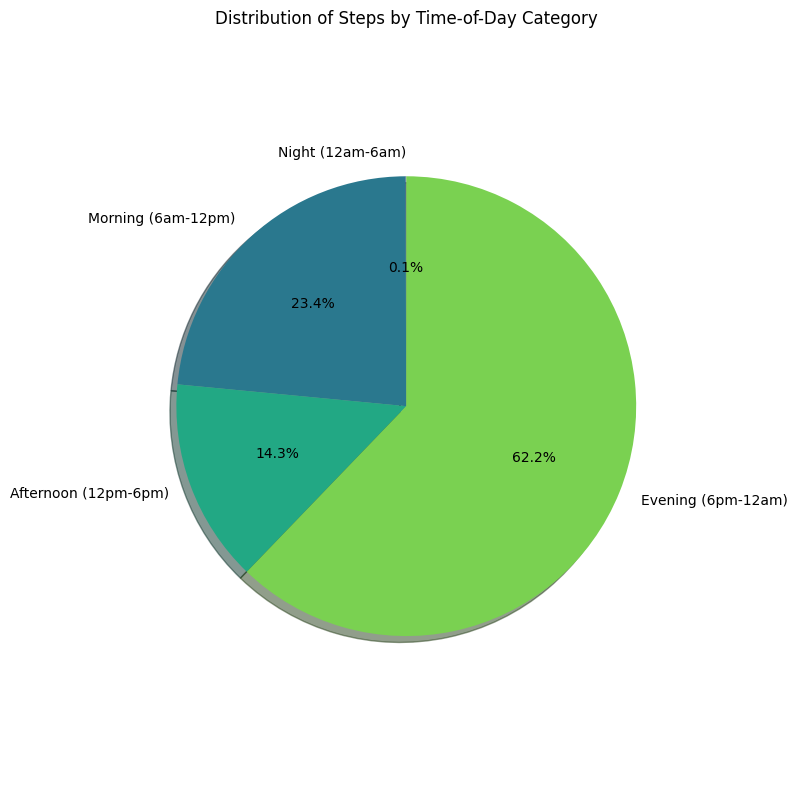

In [36]:
plt.figure(figsize=(8, 8))
plt.pie(steps_by_time_category, labels=steps_by_time_category.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(steps_by_time_category)),shadow=True)
plt.title('Distribution of Steps by Time-of-Day Category')
plt.axis('equal')
plt.tight_layout()
plt.show()